# DeepSketch Phase 2 — Kaggle Training Notebook
Train Pix2Pix for `sketch -> stylized color portrait`.
This notebook orchestrates repository scripts only; no model/training logic is duplicated here.

## 1. Check Kaggle GPU & Setup Environment

In [1]:
import os
import torch

os.environ['WANDB_MODE'] = 'disabled'
print('PyTorch Version:', torch.__version__)
print('CUDA Available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch Version: 2.9.0+cu126
CUDA Available: True
GPU: Tesla T4


## 2. Clone the GitHub Repository

In [2]:
!rm -rf deep-sketch
!git clone https://github.com/supratimcoder1/deep-sketch.git
%cd deep-sketch

Cloning into 'deep-sketch'...
remote: Enumerating objects: 191, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 191 (delta 77), reused 127 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (191/191), 11.07 MiB | 16.05 MiB/s, done.
Resolving deltas: 100% (77/77), done.
/kaggle/working/deep-sketch


## 3. Install Dependencies

In [3]:
!pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 58.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 23.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.23 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.


## 4. Verify Kaggle Dataset Location

In [4]:
from pathlib import Path
import os

dataset_root = Path('/kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset')
photos_src = dataset_root / 'photos'
sketches_src = dataset_root / 'sketches'
sketches_src2 = dataset_root / 'sketches_p1'
stylized_src = dataset_root / 'stylized'

print('photos exists:', photos_src.exists())
print('sketches exists:', sketches_src.exists())
print('generated sketches exists:', sketches_src2.exists())
print('stylized exists:', stylized_src.exists())

if not photos_src.exists() or not sketches_src.exists() or not stylized_src.exists():
    raise FileNotFoundError('Expected /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/{photos,sketches,stylized}')

print('Photos found:', len(os.listdir(photos_src)))
print('Sketches found:', len(os.listdir(sketches_src)))
print('Generated Sketches found:', len(os.listdir(sketches_src2)))
print('Stylized found:', len(os.listdir(stylized_src)))

photos exists: True
sketches exists: True
generated sketches exists: True
stylized exists: True
Photos found: 188
Sketches found: 188
Generated Sketches found: 188
Stylized found: 188


## 5. Create Dataset Symlinks
Link Kaggle input folders into the repo's expected `dataset/` structure.

In [5]:
!rm -rf dataset
!mkdir -p dataset
!ln -s /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/photos dataset/photos
!ln -s /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/sketches dataset/sketches
!ln -s /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/sketches_p1 dataset/sketches_p1
!ln -s /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/stylized dataset/stylized
!ls -la dataset/

print(len(os.listdir('dataset/photos')))
print(len(os.listdir('dataset/sketches')))
print(len(os.listdir('dataset/sketches_p1')))
print(len(os.listdir('dataset/stylized')))

total 24
drwxr-xr-x 2 root root 4096 Mar 19 05:16 .
drwxr-xr-x 8 root root 4096 Mar 19 05:16 ..
lrwxrwxrwx 1 root root   81 Mar 19 05:16 photos -> /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/photos
lrwxrwxrwx 1 root root   83 Mar 19 05:16 sketches -> /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/sketches
lrwxrwxrwx 1 root root   86 Mar 19 05:16 sketches_p1 -> /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/sketches_p1
lrwxrwxrwx 1 root root   83 Mar 19 05:16 stylized -> /kaggle/input/datasets/supratimghosh01/cufs-dataset-clean-stylized/dataset/stylized
188
188
188
188


## 6. Start Phase 2 Training

In [6]:
!python phase2/training/train.py --epochs 500

Using device: cuda
AMP enabled: True
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|█████████████████████████████████████████| 528M/528M [00:02<00:00, 232MB/s]
Train samples: 170  |  Val samples: 18
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://d

## 7. Inspect Training Outputs
Display the latest generated sample grid.

Showing: samples/phase2/epoch_0500.png


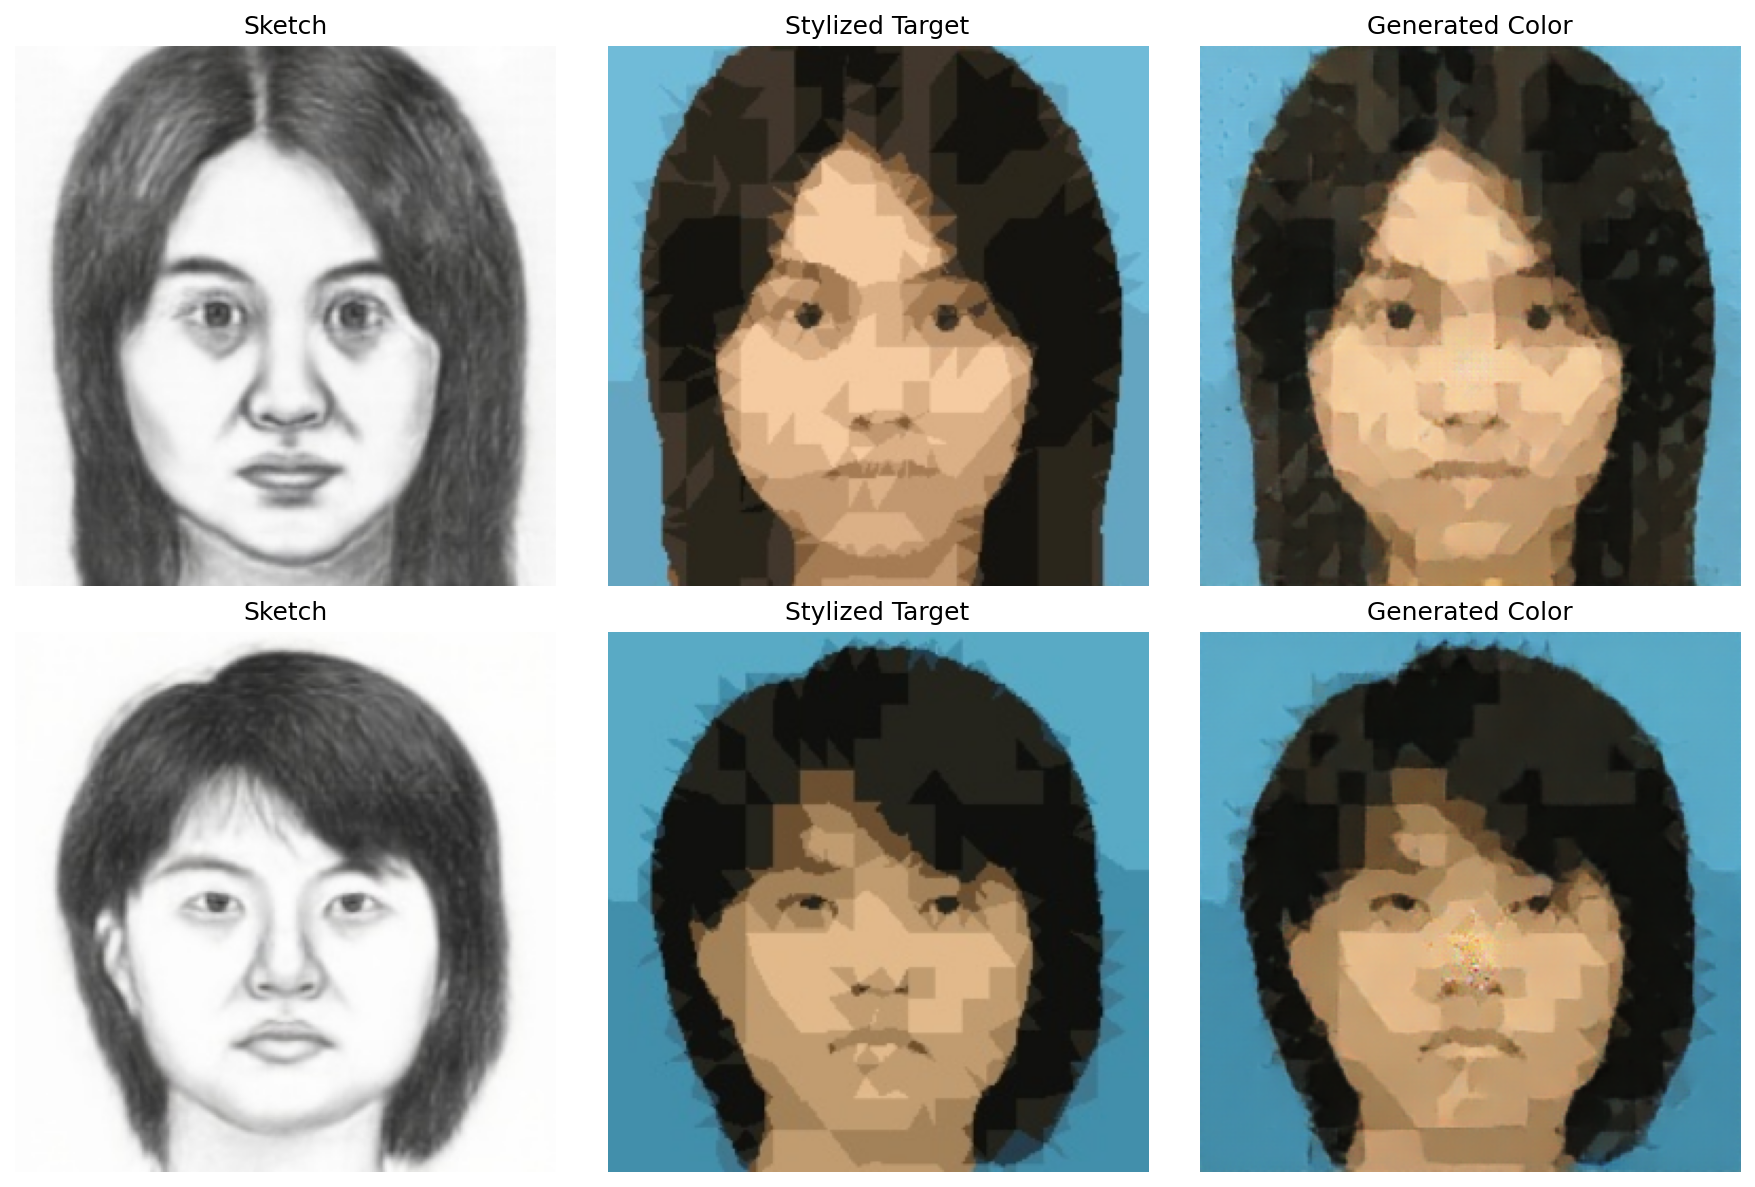

In [7]:
import glob
from IPython.display import display, Image as IPImage

sample_files = sorted(glob.glob('samples/phase2/epoch_*.png'))
if sample_files:
    latest = sample_files[-1]
    print(f'Showing: {latest}')
    display(IPImage(filename=latest, width=900))
else:
    print('No sample images found — training may not have completed.')

## 8. Quick Inference Preview

Using device: cuda
Stylized portrait saved to phase2_preview.png


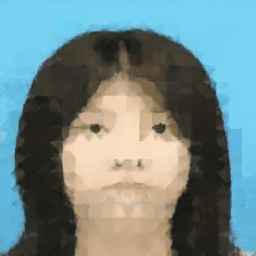

In [8]:
import os
from IPython.display import display, Image as IPImage

first_sketch = sorted(os.listdir('dataset/sketches_p1'))[0]
input_path = f'dataset/sketches_p1/{first_sketch}'

!python phase2/inference/generate_color.py --input $input_path --output phase2_preview.png --checkpoint phase2/checkpoints/best_generator.pth
display(IPImage(filename='phase2_preview.png', width=600))

## 9. Package Outputs for Download
Zip best checkpoint so it appears in Kaggle output.

In [9]:
!zip -r phase2_bestmodel.zip phase2/checkpoints/best_generator.pth
print('Created best_generator.pth in phase2_bestmodel.zip')

  adding: phase2/checkpoints/best_generator.pth (deflated 7%)
Created best_generator.pth in phase2_bestmodel.zip
